# Auto-immune dataset - Milo differential abundance analysis example

Example workflows for more details:

- [Milopy vignette](https://nbviewer.org/github/emdann/milopy/blob/master/notebooks/milopy_example.ipynb)
- [Extended milo example](https://github.com/Teichlab/scripts/blob/main/conditions/extended_milopy_example.ipynb)

In [ ]:
import os,sys
import numpy as np
import pandas as pd
import scanpy as sc


In [ ]:
import sys
sys.path.append('/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/AIID_notebooks/')

from inflapy.immunoFunc import *

In [ ]:
print(sc.__version__)

1.9.1


In [ ]:
import milopy.core as milo
import milopy

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import random
import sc_toolbox

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

### Load integrated dataset

In [ ]:
def load_sub_adata(adata, obs_file):
    obs = pd.read_csv(obs_file, index_col=0)
    if "scvi_clusters" in obs.columns:
        obs.drop(columns="scvi_clusters", inplace=True)
    temp = adata[obs.index].copy()
    temp.obs = obs
    return temp

def load_scvi_outs(adata, emb_file):
    X_scVI_emb = np.load(emb_file)
    X_scVI_umap = np.load(emb_file.rstrip("_scANVI.scVI_out.npy") + "_scANVI.UMAP.npy")
    #X_scVI_clust = pd.read_csv(emb_file.rstrip("_scANVI.scVI_out.npy") + "_scANVI.clustering.csv", index_col=0)
    adata.obsm["X_scANVI"] = X_scVI_emb
    adata.obsm["X_umap"] = X_scVI_umap
    #adata.obs["scvi_clusters"] = X_scVI_clust.loc[adata.obs_names]["leiden_1_5"].astype("category")

In [ ]:
adata = sc.read_h5ad("/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/B_From_PBMC_Subset_2_Reintegr_after_label_trans.h5ad")


In [ ]:
dir_save="/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/"

In [ ]:
adata

AnnData object with n_obs × n_vars = 98281 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'batch', 'n_genes', 'leiden_1_5', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'majority_voting', 'conf_score', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_R', 'leiden_man'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'feature_biotype-1-0-0-0-0', 'feature_is_filtered-1-0-0-0-0', 'feature_name-1-0-0-0-0', 'feature_reference-1-0-0-0-0', 'feature_bioty

In [ ]:
adata = adata[-adata.obs.Cell_type_scANVI.isin(['Unknown', 'Megakaryocyte precursor', 'HSC/MPP'])].copy()

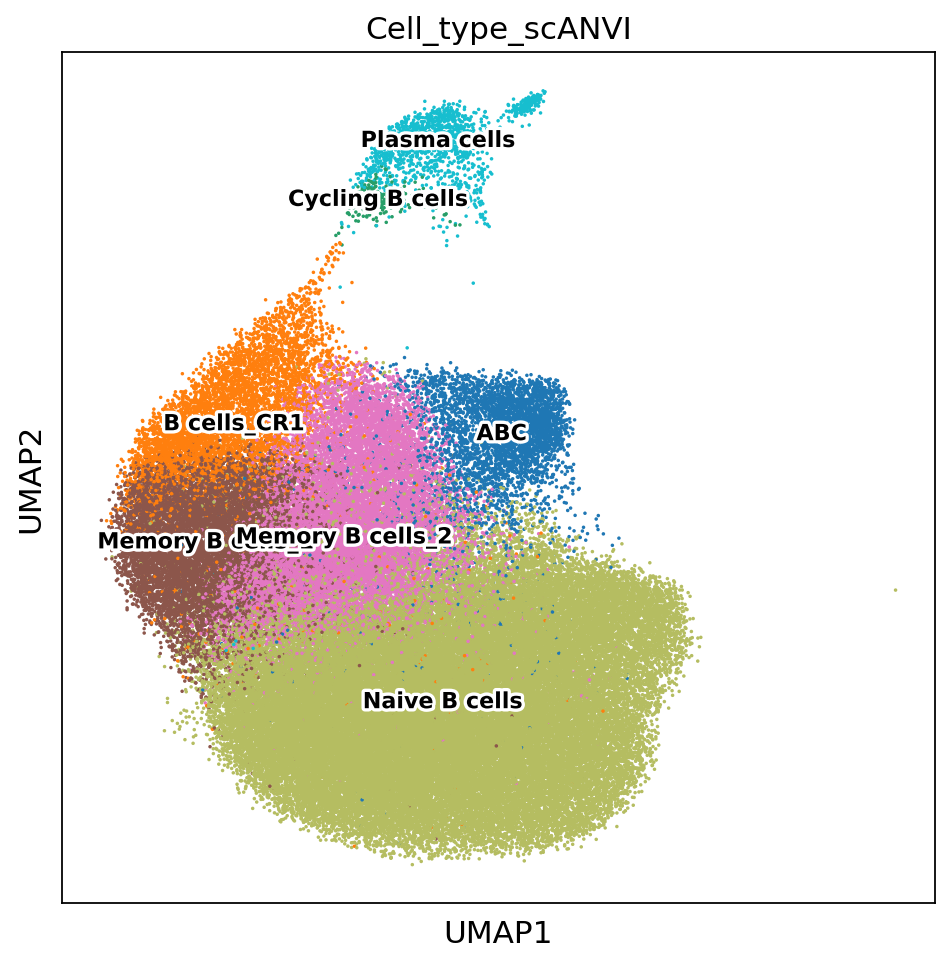

In [ ]:
sc.set_figure_params(figsize=(7,7))
sc.pl.umap(
    adata,
    color=["Cell_type_scANVI"],
    ncols=2,
    frameon=True,
    size=10,
    legend_fontoutline=3,
    legend_fontsize=10,
    legend_loc="on data",
    cmap='OrRd'

)

In [ ]:
adata.obs.Cell_type_scANVI.value_counts(dropna=False)

Naive B cells       57002
Memory B cells_2    16904
Memory B cells_1    10037
B cells_CR1          5893
ABC                  4255
Plasma cells         1526
Cycling B cells       220
Name: Cell_type_scANVI, dtype: int64

In [ ]:
adata.shape

(95837, 20301)

We will keep only donors with average 10 cells in each cluster

In [ ]:
ncel = len(adata.obs.Cell_type_scANVI.unique())

In [ ]:
size_by_donor = adata.obs.groupby(["donor_id"]).size()

In [ ]:
donors_to_keep = [
    donor
    for donor in size_by_donor.index
    if size_by_donor[donor] >= 10*ncel
]

In [ ]:
len(donors_to_keep)

225

In [ ]:
len(adata.obs.donor_id.unique())

295

In [ ]:
donors_to_keep[:10]

['0a0c1c97-6ee8-4ac7-acc0-298fe1f45bc5',
 '0e976519-2477-4e53-bb3a-4322ee2ec163',
 '1a80b7d3-dd95-4b5a-bb30-33b17b3ead13',
 '1bed79e5-39d1-461e-a189-7a70e95b250d',
 '1c2ab600-edb3-476b-a335-e82a639cc01b',
 '1d0c9aa0-f3e6-4c13-be75-73a7fd61338b',
 '1d8daffc-3a35-4d5c-95e3-0ef93ef6a90c',
 '1d15a70f-8b4c-4d49-a08b-c7098cd3b170',
 '1d64c1cf-4e1e-4e4f-beca-c3a4df36fdcf',
 '2a3821dd-89d1-4f22-b36e-6d2630e71e16']

In [ ]:
adata = adata[adata.obs["donor_id"].isin(donors_to_keep)]

In [ ]:
adata.shape

(93555, 20301)

In [ ]:
adata.obs.disease.value_counts()

Healthy                         47698
Systemic lupus erythematosus    29443
Oligoarticular JIA               4376
Crohn's Disease                  4349
Hashimoto’s thyroiditis          2841
Sjögren’s syndrome               2042
CD + Spondyloarthritis           1658
Spondyloarhtritis                1148
Name: disease, dtype: int64

In [ ]:
adata.write_h5ad(dir_save+"B_From_PBMC_Subset_2_Reintegr_after_label_trans.h5ad")

#adata = sc.read_h5ad(dir_save+"scANVI_Myeloid_cells_out/Myeloid_cell_from_PBMC_scANVI.h5ad")


In [ ]:
gc.collect()

17

In [ ]:
sample_cols = ['dataset_id', 'donor_id', 'tissue', 'disease', 'cell_source', 'Cell_type_scANVI']
sample_df = adata.obs[sample_cols].groupby(sample_cols).size().reset_index()
sample_df.columns = sample_cols + ['n_cells']
sample_df = sample_df[sample_df['n_cells'] > 0].copy()
sample_df

,dataset_id,donor_id,tissue,disease,cell_source,Cell_type_scANVI,n_cells
7007,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,ABC,5
7008,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,B cells_CR1,35
7010,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,Memory B cells_1,43
7011,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,Memory B cells_2,51
7012,GSE134809_Martin_et_al_2019,GSM4761137,Blood,Crohn's Disease,PBMC,Naive B cells,318
...,...,...,...,...,...,...,...
70856,Qian_Yue_Zhang_2022,HT29PBMC,Blood,Hashimoto’s thyroiditis,PBMC,Cycling B cells,9
70857,Qian_Yue_Zhang_2022,HT29PBMC,Blood,Hashimoto’s thyroiditis,PBMC,Memory B cells_1,54
70858,Qian_Yue_Zhang_2022,HT29PBMC,Blood,Hashimoto’s thyroiditis,PBMC,Memory B cells_2,85
70859,Qian_Yue_Zhang_2022,HT29PBMC,Blood,Hashimoto’s thyroiditis,PBMC,Naive B cells,257


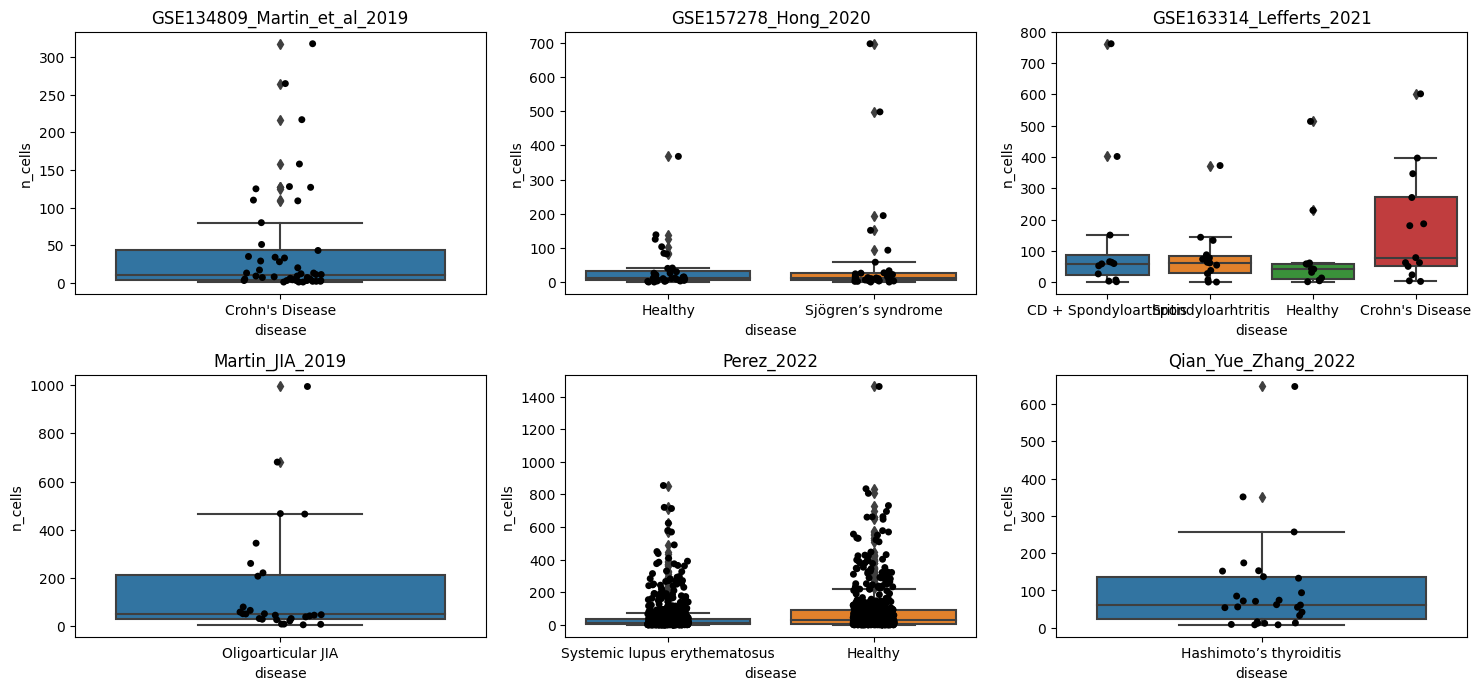

In [ ]:
all_datasets = sample_df['dataset_id'].unique()
all_diseases = sample_df['disease'].unique()

with plt.rc_context({'figure.figsize':[15,10]}):
    for i,d in enumerate(all_datasets):
        plt.subplot(3,3,i+1);
        d_df = sample_df[sample_df.dataset_id == d].copy()
        d_df['disease'] = d_df['disease'].astype('str')
        sns.boxplot(
            data = d_df,
            x = 'disease',
            y = 'n_cells'
        );
        sns.stripplot(
            data = d_df,
            x = 'disease',
            y = 'n_cells',
            color = 'black'
        );
        plt.title(d);
    plt.tight_layout()
    plt.show()

Check sample metadata

In [ ]:
all_diseases

['Crohn's Disease', 'Healthy', 'Sjögren’s syndrome', 'CD + Spondyloarthritis', 'Spondyloarhtritis', 'Oligoarticular JIA', 'Systemic lupus erythematosus', 'Hashimoto’s thyroiditis']
Categories (8, object): ['CD + Spondyloarthritis', 'Crohn's Disease', 'Hashimoto’s thyroiditis', 'Healthy', 'Oligoarticular JIA', 'Sjögren’s syndrome', 'Spondyloarhtritis', 'Systemic lupus erythematosus']

In [ ]:
sample_df['disease'].value_counts()

Systemic lupus erythematosus    641
Healthy                         559
Crohn's Disease                  58
Sjögren’s syndrome               34
Oligoarticular JIA               28
Hashimoto’s thyroiditis          27
Spondyloarhtritis                14
CD + Spondyloarthritis           12
Name: disease, dtype: int64

In [ ]:
adata.obs.disease.unique()

['Hashimoto’s thyroiditis', 'Systemic lupus erythematosus', 'Healthy', 'Oligoarticular JIA', 'Crohn's Disease', 'CD + Spondyloarthritis', 'Spondyloarhtritis', 'Sjögren’s syndrome']
Categories (8, object): ['CD + Spondyloarthritis', 'Crohn's Disease', 'Hashimoto’s thyroiditis', 'Healthy', 'Oligoarticular JIA', 'Sjögren’s syndrome', 'Spondyloarhtritis', 'Systemic lupus erythematosus']

In [ ]:
## Rename disease (DA code complains because of weird characters in names)
diseases_short = {
    'CD + Spondyloarthritis':"CD_and_spondoarthritis",#
    'Spondyloarhtritis':"spondoarthritis",#
    "Crohn's Disease":"CD",#
    'Healthy':'Healthy',#
    'Hashimoto’s thyroiditis':'hashimoto',#
    'Oligoarticular JIA':'Oligo_JIA',#
    'Systemic lupus erythematosus':'SLE',#
    "Sjögren’s syndrome":'sjo_syndr'#
}

In [ ]:
# diseases_short = {v:k for k,v in diseases_short.items()}

In [ ]:
adata.obs['disease_short'] = [diseases_short[x] for x in adata.obs['disease']]
# sample_col = 'donor_id'
# condition_col = 'disease'

### Make neighbourhoods

In [ ]:
#adata = adata[-adata.obs.Cell_type_scANVI.str.startswith("Megaka")]

In [ ]:
gc.collect()
adata

AnnData object with n_obs × n_vars = 93555 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'batch', 'n_genes', 'leiden_1_5', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'majority_voting', 'conf_score', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_R', 'leiden_man', 'disease_short'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'feature_biotype-1-0-0-0-0', 'feature_is_filtered-1-0-0-0-0', 'feature_name-1-0-0-0-0', 'feature_reference-1-0-0-0-0

In [ ]:
## Make KNN graph for Milo analysis 
k = (sample_df['donor_id'].nunique() * 3) # aim to have 3 cells per donor on avg
sc.pp.neighbors(adata, use_rep='X_scANVI', n_neighbors = k)

In [ ]:
milo.make_nhoods(adata, prop=0.15)

In [ ]:
len(adata.obs.donor_id.unique())

225

Plot number of cells in neighbourhoods

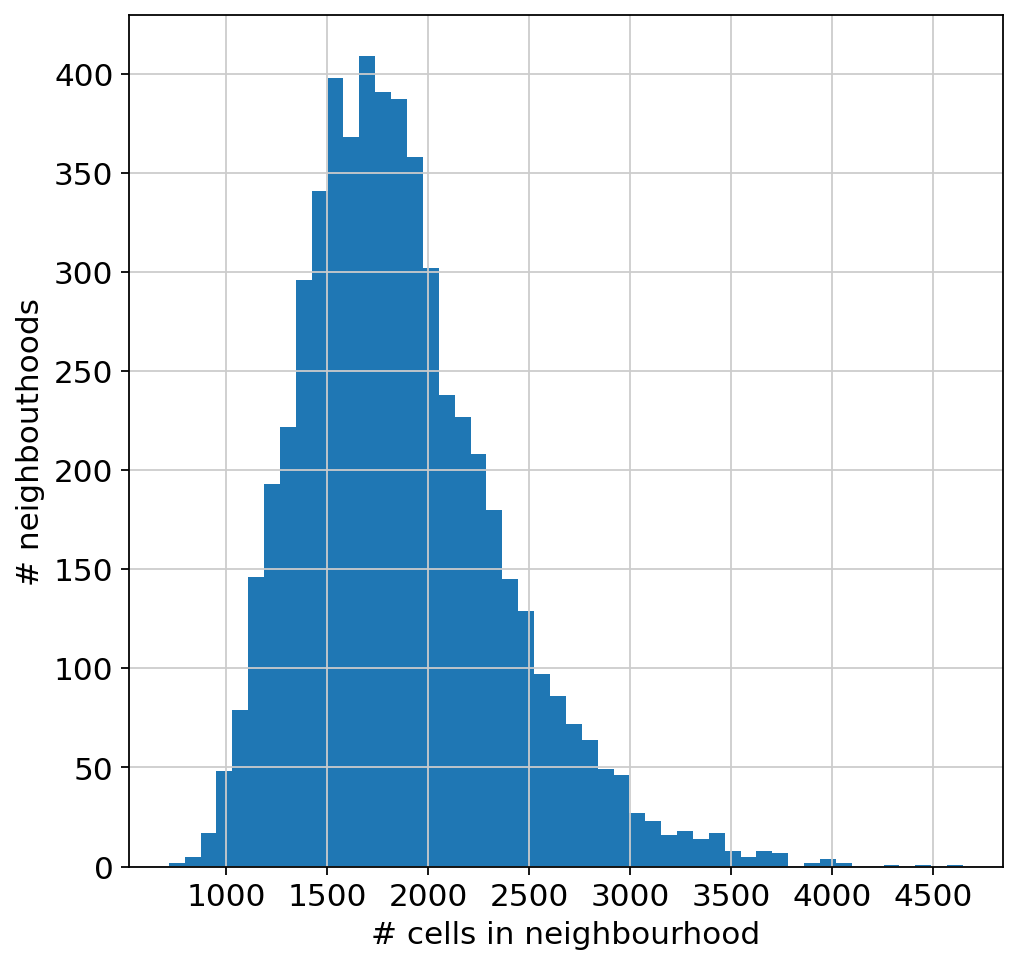

In [ ]:
nhood_size = adata.obsm['nhoods'].toarray().sum(0)
plt.hist(nhood_size, bins=50);
plt.xlabel('# cells in neighbourhood');
plt.ylabel('# neighbouthoods');

### Count cells in neighbourhoods

In [ ]:
adata.obs['donor_id'] = adata.obs['donor_id'].astype('str') ## Needed for subsetting
milo.count_nhoods(adata, sample_col = 'donor_id')

In [ ]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'


#adata.write_h5ad(h5ad_path+'B_From_PBMC_label_transfert_Subset_annotated_Milo_3K.h5ad')

adata = sc.read_h5ad(h5ad_path+'B_From_PBMC_label_transfert_Subset_annotated_Milo_3K.h5ad')

In [ ]:
sample_cols = ['dataset_id', 'donor_id', 'tissue', 'disease', 'cell_source', 'Cell_type_scANVI']
sample_df = adata.obs[sample_cols].groupby(sample_cols).size().reset_index()
sample_df.columns = sample_cols + ['n_cells']
sample_df = sample_df[sample_df['n_cells'] > 0].copy()

In [ ]:
adata

AnnData object with n_obs × n_vars = 93555 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'batch', 'n_genes', 'leiden_1_5', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'majority_voting', 'conf_score', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_R', 'leiden_man', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'feature_biotype-1-0-0-0-0', 'feature_is_filtered-1-0

In [ ]:
import gc
gc.collect()

34

## Run differential abundance test

### 1. Use paired case-controls

For each test restrict to case-control in the same disease

In [ ]:
def plot_milo_diagnostics(milo_res):
    '''Function to plot diagnostic plots 
    as in extended vignette https://github.com/Teichlab/scripts/blob/main/conditions/extended_milopy_example.ipynb
    '''
    nhood_adata = adata.uns['nhood_adata'].copy()
    alpha = 0.1 ## significance threshold

    with matplotlib.rc_context({'figure.figsize':[8,8]}):

        ## Check P-value histogram
        plt.subplot(2,2,1);
        plt.hist(milo_res['PValue'], bins=20);
        plt.xlabel('Uncorrected P-value');

        ## Visualize extent of multiple-testing correction
        plt.subplot(2,2,2);
        plt.scatter(milo_res['PValue'], milo_res['SpatialFDR'], s=3);
        plt.xlabel('Uncorrected P-value');
        plt.ylabel('SpatialFDR');

        ## Visualize volcano plot
        plt.subplot(2,2,3);
        plt.scatter(milo_res['logFC'], -np.log10(milo_res['SpatialFDR']), s=3);
        plt.axhline(y=-np.log10(alpha), color='red', linewidth=1, label=f'{int(alpha*100)} % SpatialFDR');
        plt.legend();
        plt.xlabel('log-Fold Change');
        plt.ylabel('- log10(SpatialFDR)');
        plt.tight_layout()

        ## Visualize MA plot
        df = milo_res
        emp_null = df[df['SpatialFDR'] >= alpha]['logFC'].mean()
        df['Sig'] = df['SpatialFDR'] < alpha

        plt.subplot(2,2,4);
        sns.scatterplot(data=df, x="logCPM", y="logFC", hue='Sig')
        plt.axhline(y=0, color='grey', linewidth=1)
        plt.axhline(y=emp_null, color='purple', linewidth=1);
        plt.legend(title=f'< {int(alpha*100)} % SpatialFDR')
        plt.xlabel('Mean log-counts');
        plt.ylabel('log-Fold Change');
        plt.show()
        
def run_DA_autoimmune(adata, sample_df, DA_test_dict):
    '''Wrapper function to run differential abundance testing on autoimmune dataset
    '''
    
    adata.obs['disease_test'] = np.where(adata.obs['disease'].isin(DA_test_dict['disease']), 1, 0)
    
    test_samples = sample_df['donor_id'][sample_df['dataset_id'] == DA_test_dict['dataset_id']].astype('str').values
    
    milo.DA_nhoods(adata, 
                   design="~ donor_id + disease_test",
                   subset_samples=test_samples.tolist()
                  )
    milo_results = adata.uns["nhood_adata"].obs.copy() ## Store results for each disease
    plot_milo_diagnostics(milo_results.dropna())
    return(milo_results)


In [ ]:
np.unique(adata.obs.dataset_id)

array(['GSE134809_Martin_et_al_2019', 'GSE157278_Hong_2020',
       'GSE163314_Lefferts_2021', 'Martin_JIA_2019', 'Perez_2022',
       'Qian_Yue_Zhang_2022'], dtype=object)

In [ ]:
adata.obs[["dataset_id", "disease"]].value_counts().sort_index()

dataset_id                   disease                     
GSE134809_Martin_et_al_2019  Crohn's Disease                  2076
GSE157278_Hong_2020          Healthy                          1251
                             Sjögren’s syndrome               2042
GSE163314_Lefferts_2021      CD + Spondyloarthritis           1658
                             Crohn's Disease                  2273
                             Healthy                          1069
                             Spondyloarhtritis                1148
Martin_JIA_2019              Oligoarticular JIA               4376
Perez_2022                   Healthy                         45378
                             Systemic lupus erythematosus    29443
Qian_Yue_Zhang_2022          Hashimoto’s thyroiditis          2841
dtype: int64

In [ ]:
DA_test_dict = {
    ## Define parameters for each test
    'martin_cd':{'dataset_id':'GSE134809_Martin_et_al_2019', 'disease':["Crohn's Disease"]},#
    'martin_uninfl_CD':{'dataset_id':'GSE134809_Martin_et_al_2019', 'disease':["Uninflamed CD"]},
    'stefeno_RA':{'dataset_id':'E-MTAB-8322_Stefeno_2020', 'disease':['Rheumatoid Arthritis']},
    'stefeno_undef_RA':{'dataset_id':'E-MTAB-8322_Stefeno_2020', 'disease':['Undifferentiated Arthritis']},
    'lefferts_spondy':{'dataset_id':'GSE163314_Lefferts_2021', 'disease':['Spondyloarthritis']},#
    'lefferts_cd_spon':{'dataset_id':'GSE163314_Lefferts_2021', 'disease':['CD + Spondyloarthritis']},#
    'lefferts_cd':{'dataset_id':'GSE163314_Lefferts_2021', 'disease':["Crohn's Disease"]},#
    #'huang_paed_IBD':{'dataset_id':'GSE121380_Huang_2019', 'disease':['Paediatric IBD']},
    'Elmentaite_2020':{'dataset_id':'Elmentaite_2020', 'disease':["Crohn's Disease"]},
    #'amp_RA':{'dataset_id':'AMP_phase1_RA', 'disease':['Rheumatoid Arthritis']},
    #'amp_OA':{'dataset_id':'AMP_phase1_RA', 'disease':['Osteoarthritis']},
    #'abji_psoriasticA':{'dataset_id':'GSE161500_Abji_2020', 'disease':['Psoriatic arthritis']},
    #'martin_JIA':{'dataset_id':'Martin_JIA_2019', 'disease':['Oligoarticular JIA']},
    #'qian_hashi':{'dataset_id':'Qian_Yue_Zhang_2022', 'disease':['Hashimoto’s thyroiditis']}
}

In [ ]:
DA_test_res = {}

In [ ]:
#for k in DA_test_dict.keys():
  #  print(k)
 #   DA_test_res[k] = run_DA_autoimmune(adata, sample_df, DA_test_dict=DA_test_dict[k])

Comments:

- Except for the Hong dataset, in all other cases there seems to be too little replicates per condition to detect significant differential abundance in this dataset

### 2. Use all healthy as controls

Tricky because we can't control for the batch effect between datasets (for some conditions we don't have data from all the datasets)

In [ ]:
diseases_short

{'CD + Spondyloarthritis': 'CD_and_spondoarthritis',
 'Spondyloarhtritis': 'spondoarthritis',
 "Crohn's Disease": 'CD',
 'Healthy': 'Healthy',
 'Hashimoto’s thyroiditis': 'hashimoto',
 'Oligoarticular JIA': 'Oligo_JIA',
 'Systemic lupus erythematosus': 'SLE',
 'Sjögren’s syndrome': 'sjo_syndr'}

In [ ]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortCD-disease_shortHealthy'
              )
DA_test_res['all_CD'] = adata.uns['nhood_adata'].obs.copy()

In [ ]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortCD_and_spondoarthritis-disease_shortHealthy'
              )
DA_test_res['all_CD_and_spondoarthritis'] = adata.uns['nhood_adata'].obs.copy()

In [ ]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortspondoarthritis-disease_shortHealthy'
              )
DA_test_res['all_spondoarthritis'] = adata.uns['nhood_adata'].obs.copy()

In [ ]:
milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortsjo_syndr-disease_shortHealthy'
              )
DA_test_res['all_sjo_syndr'] = adata.uns['nhood_adata'].obs.copy()

milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortSLE-disease_shortHealthy'
              )
DA_test_res['all_SLE'] = adata.uns['nhood_adata'].obs.copy()


milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shorthashimoto-disease_shortHealthy'
              )
DA_test_res['all_hashimoto'] = adata.uns['nhood_adata'].obs.copy()


milo.DA_nhoods(adata, 
               design="~disease_short",
               model_contrasts='disease_shortOligo_JIA-disease_shortHealthy'
              )
DA_test_res['all_Oligo_JIA'] = adata.uns['nhood_adata'].obs.copy()

all_CD


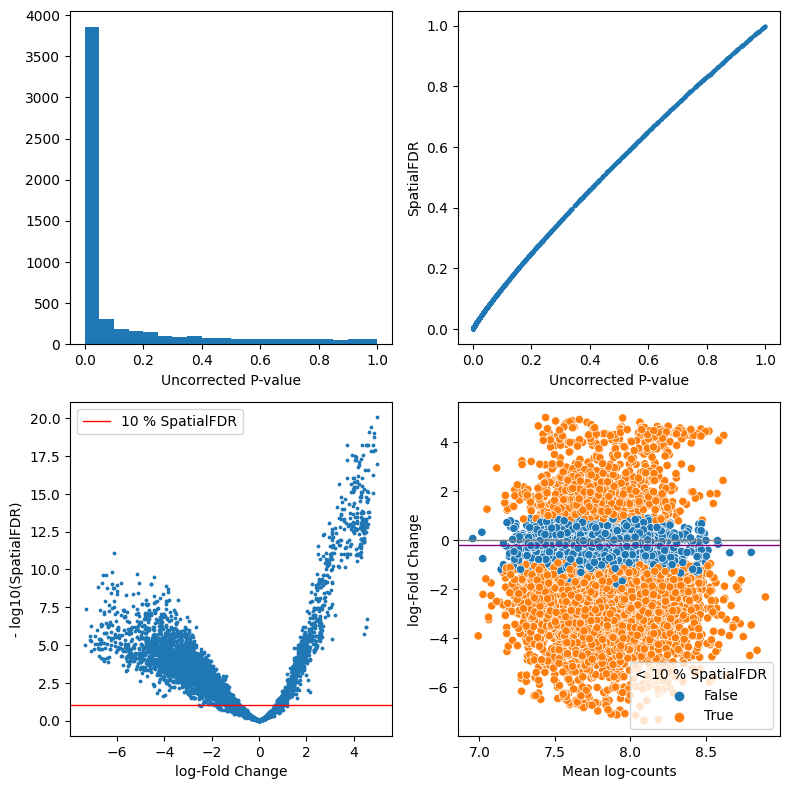

all_CD_and_spondoarthritis


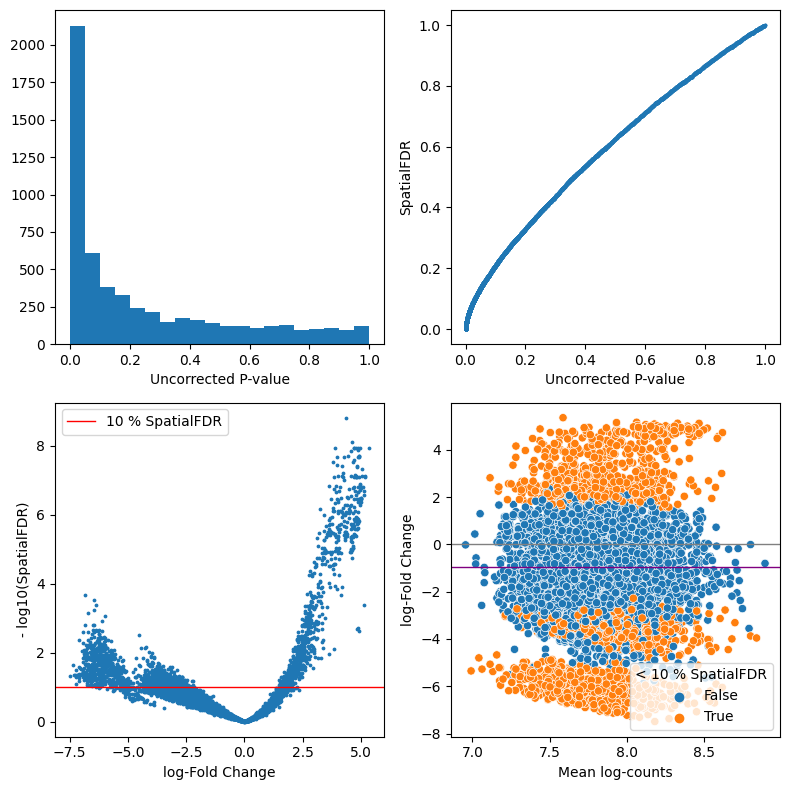

all_spondoarthritis


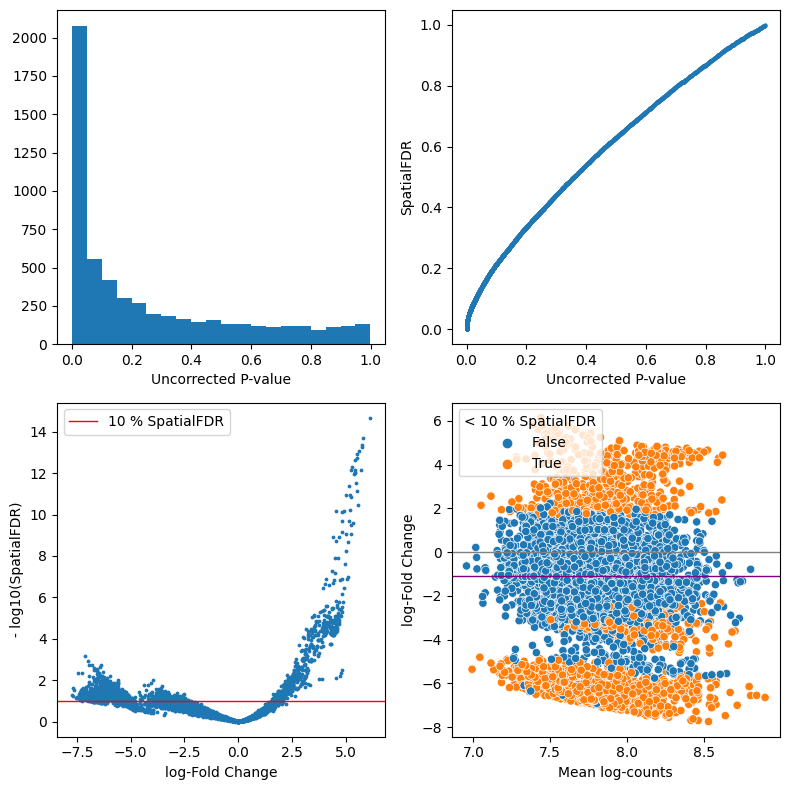

all_sjo_syndr


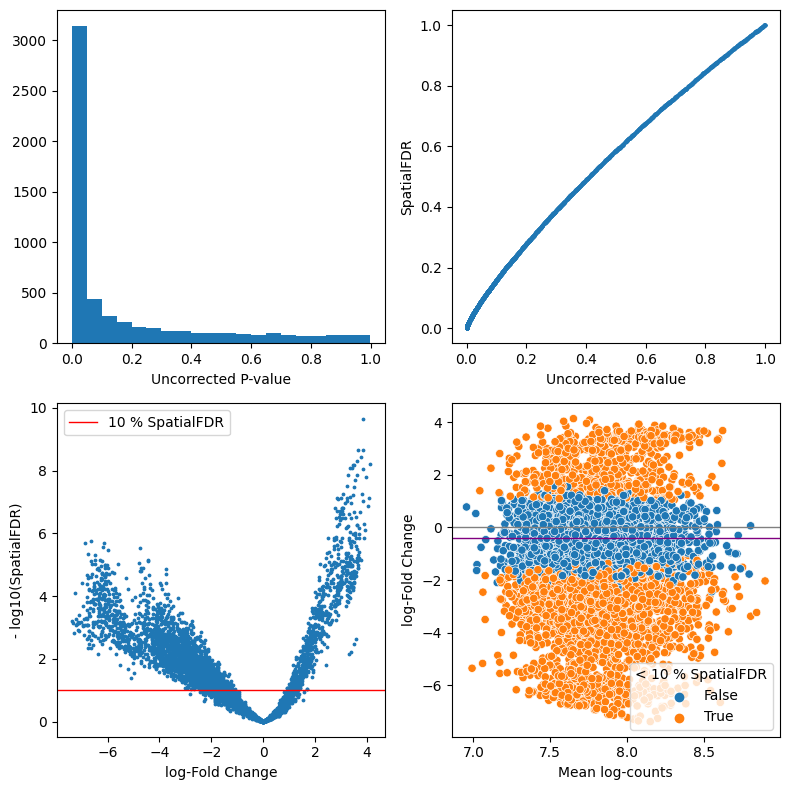

all_SLE


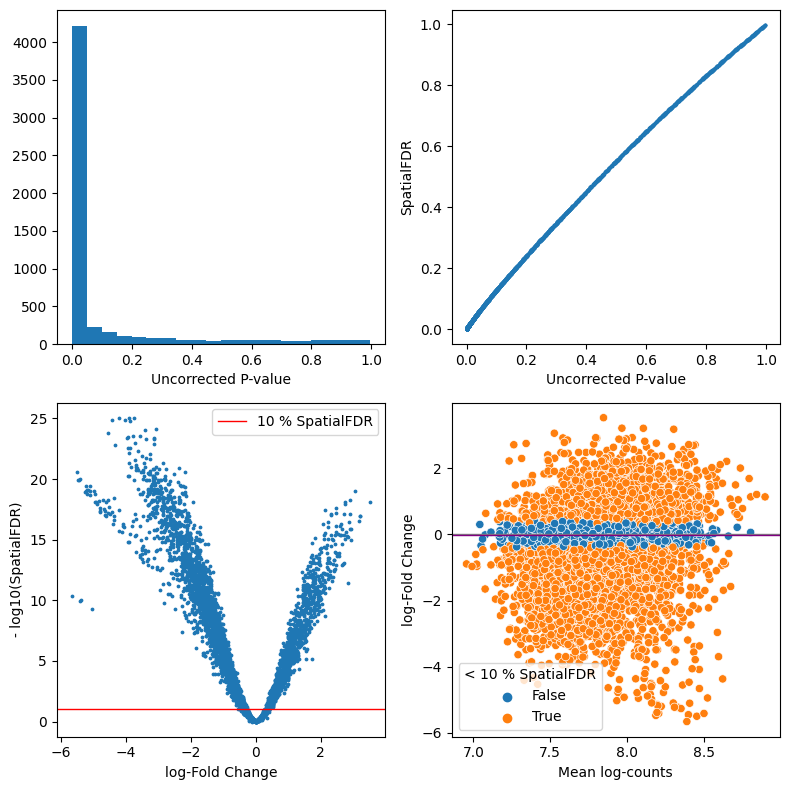

all_hashimoto


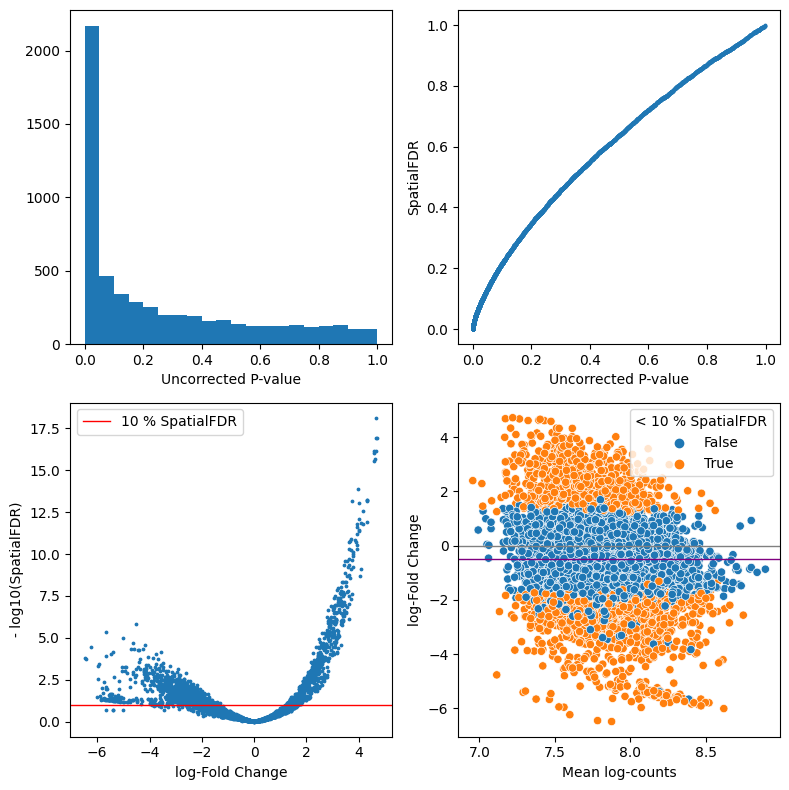

all_Oligo_JIA


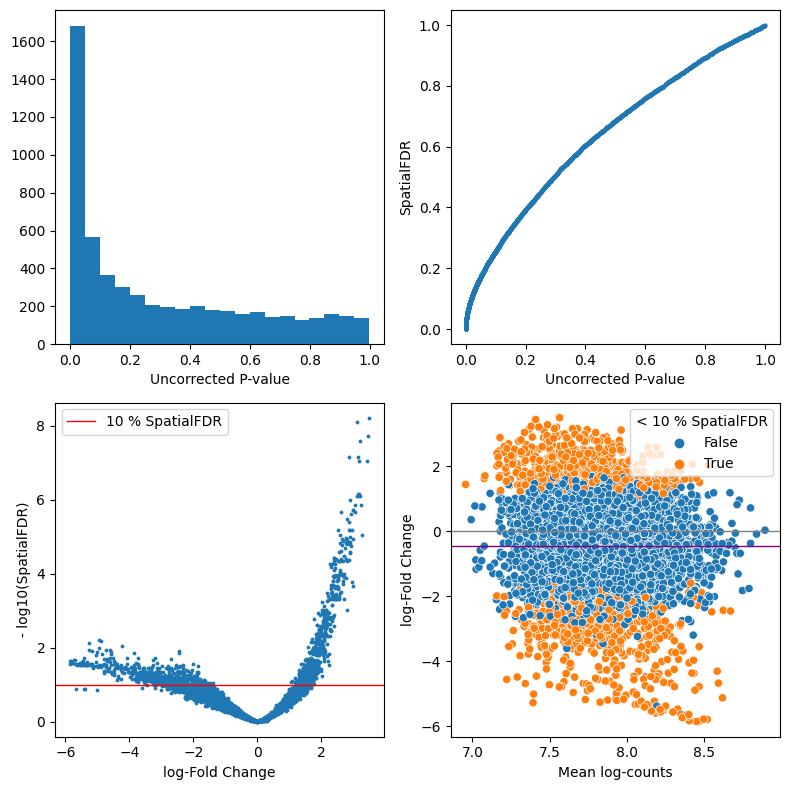

In [ ]:
for k in DA_test_res.keys():
    if k.startswith("all_"):
        print(k)
        plot_milo_diagnostics(DA_test_res[k])

Comments:

- In `all_asthma` we see skewed distribution of depleted neighbourhoods (i.e. enriched in Healthy), likely because of the imbalance in number of Healhty and disease donors
- All the others look reasonable in terms of diagnostic statistics, although we might have false positives from batch effects 

## Visualize results by cell type

We select the DA tests where the diagnostic plots look reasonable.

In [ ]:
diseases_short

{'CD + Spondyloarthritis': 'CD_and_spondoarthritis',
 'Spondyloarhtritis': 'spondoarthritis',
 "Crohn's Disease": 'CD',
 'Healthy': 'Healthy',
 'Hashimoto’s thyroiditis': 'hashimoto',
 'Oligoarticular JIA': 'Oligo_JIA',
 'Systemic lupus erythematosus': 'SLE',
 'Sjögren’s syndrome': 'sjo_syndr'}

In [ ]:
keep_tests = ["all_"+val for val in diseases_short.values() if val not in ["Healthy"]]


In [ ]:
keep_tests

['all_CD_and_spondoarthritis',
 'all_spondoarthritis',
 'all_CD',
 'all_hashimoto',
 'all_Oligo_JIA',
 'all_SLE',
 'all_sjo_syndr']

Visualize DA logFC on gene expression UMAP

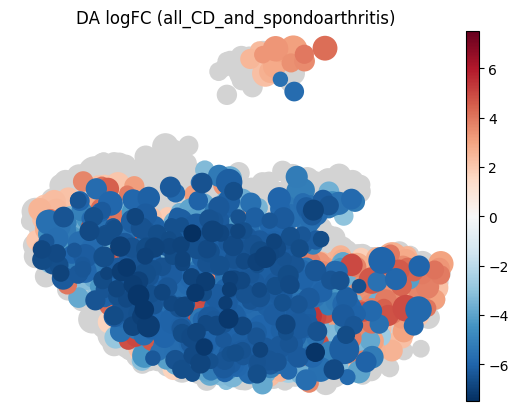

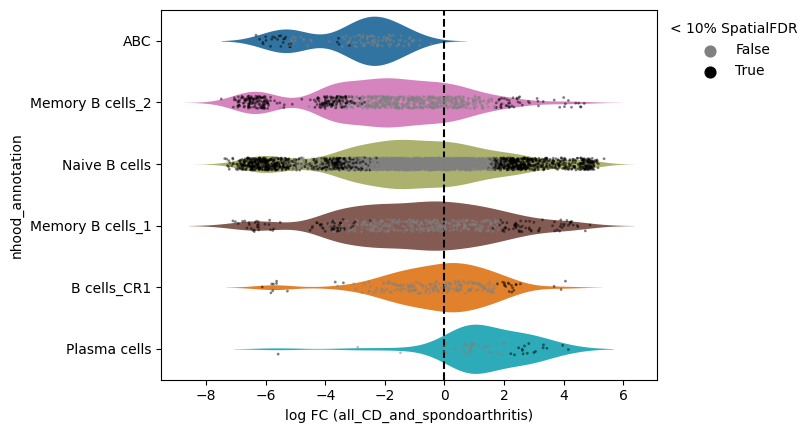

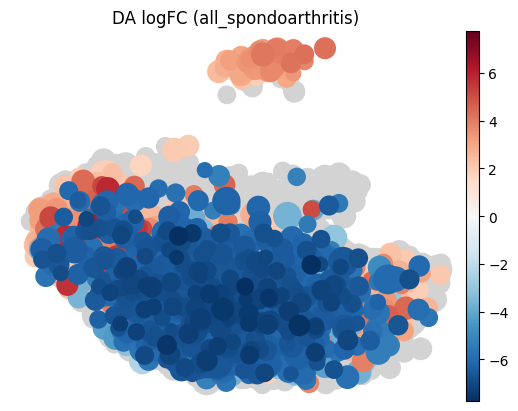

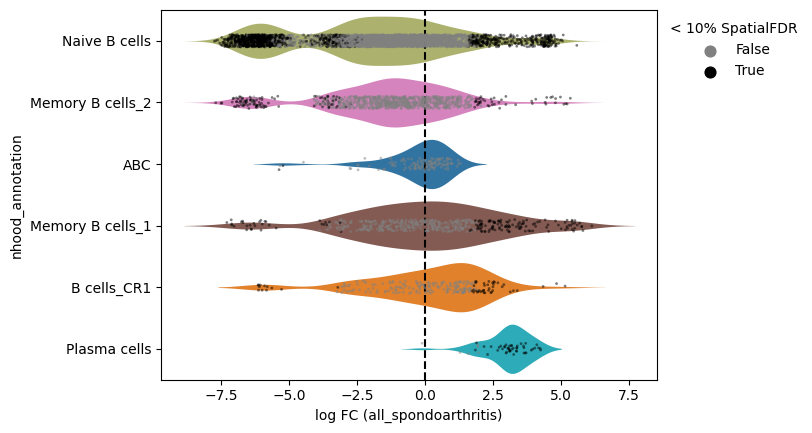

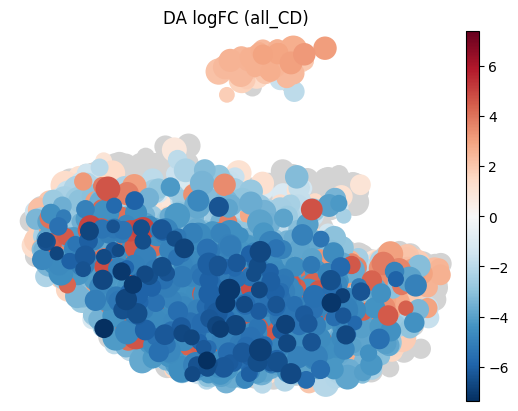

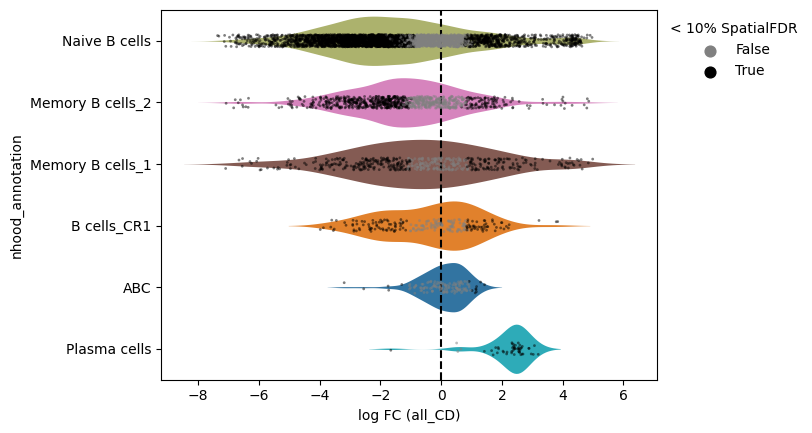

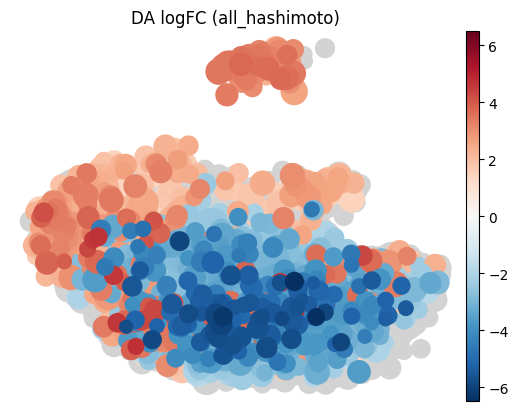

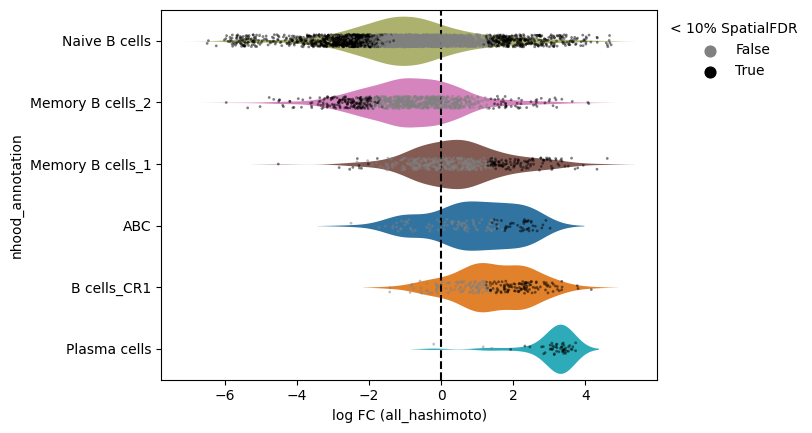

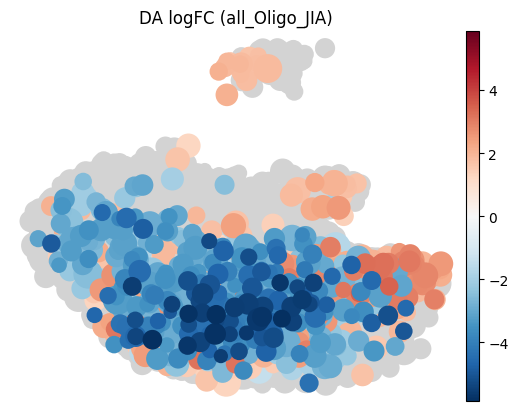

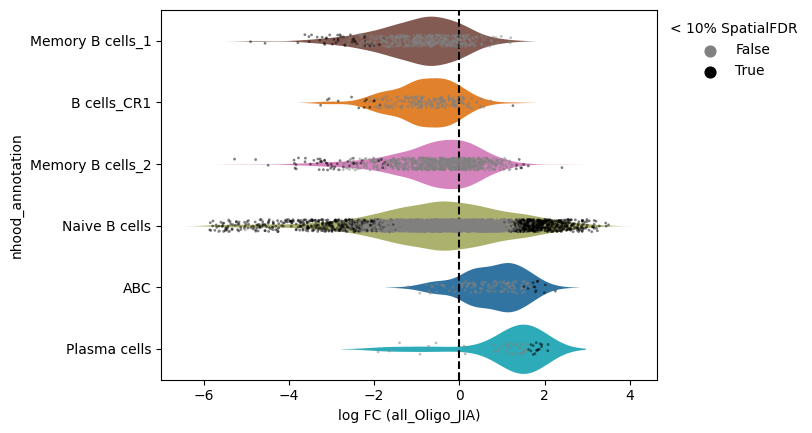

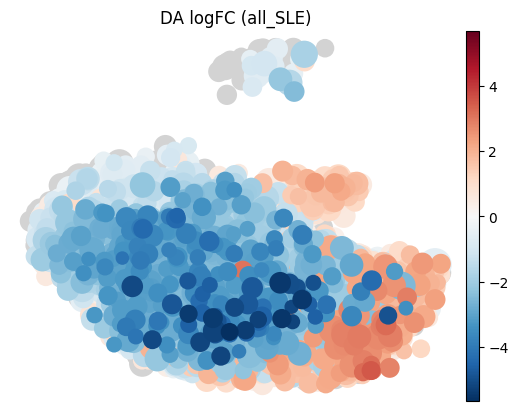

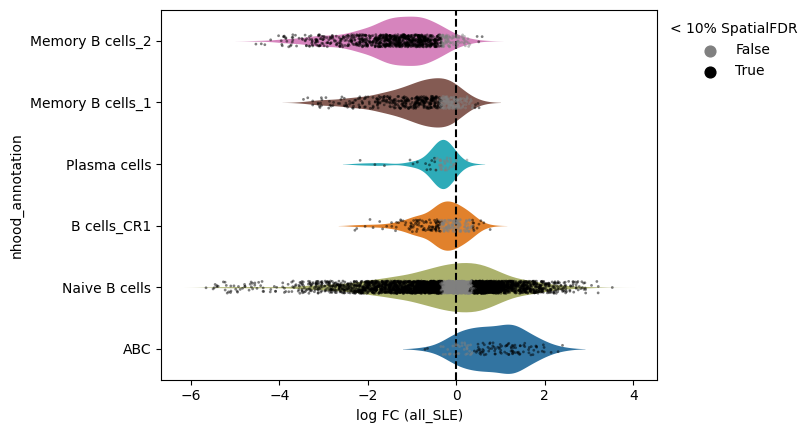

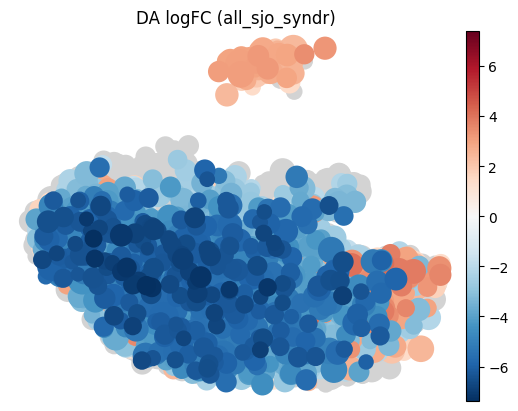

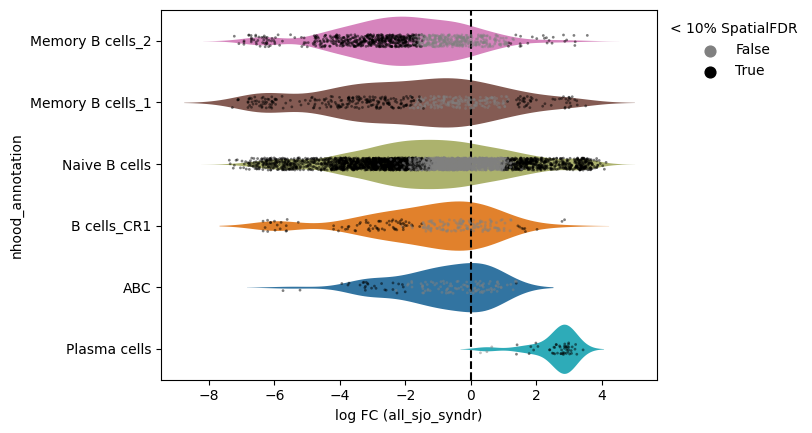

In [ ]:
for k in keep_tests:
    #if k == 'all_CD_and_spondoarthritis':
     #   continue
    
    adata.uns['nhood_adata'].obs = DA_test_res[k].copy()

    ## Plot neighbourhoods on embedding
    milopy.utils.build_nhood_graph(adata)
    milopy.plot.plot_nhood_graph(adata, alpha=0.1, min_size=0.5, title=f'DA logFC ({k})');

    ## Plot by cell type
    milopy.utils.annotate_nhoods(adata, anno_col='Cell_type_scANVI')
    milopy.plot.plot_DA_beeswarm(adata, alpha=0.1);
    plt.xlabel(f'log FC ({k})');
    plt.show()

In [ ]:
res_cols = ['logFC', 'SpatialFDR', 'Sig', 'index_cell']

In [ ]:
disease_df = []
nhood_annotation = np.array(adata.uns["nhood_adata"].obs['nhood_annotation'])
cell_ind = np.array(adata.uns["nhood_adata"].obs['index_cell'])
for disease in keep_tests:
    
    tab = DA_test_res[disease][res_cols]
    #check if index_cell columns are in the same order
    if any(np.array(adata.uns["nhood_adata"].obs['index_cell']) != tab['index_cell']):
        raise Exception("index_cell don't match...")
    tab["disease"] = np.repeat(disease, tab.shape[0])
    tab["nhood_annotation"] = nhood_annotation
    disease_df.append(tab)

In [ ]:
adata.uns["nhood_adata"].obs["Sig"].value_counts()

True     3228
False    2429
Name: Sig, dtype: int64

In [ ]:
#Check number of neighbourhoods
disease_df[0]['nhood_annotation'].value_counts()

Naive B cells       3897
Memory B cells_2     906
Memory B cells_1     464
B cells_CR1          213
ABC                  126
Plasma cells          51
Name: nhood_annotation, dtype: int64

In [ ]:
compare_disease_df = pd.concat(disease_df)

In [ ]:
compare_disease_df.disease.value_counts()

all_CD_and_spondoarthritis    5657
all_spondoarthritis           5657
all_CD                        5657
all_hashimoto                 5657
all_Oligo_JIA                 5657
all_SLE                       5657
all_sjo_syndr                 5657
Name: disease, dtype: int64

## Save


In [ ]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'


In [ ]:
compare_disease_df.to_csv(h5ad_path+"B_From_PBMC_label_transfer_Milo_3K.csv")

In [ ]:
h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/'

compare_disease_df = pd.read_csv(h5ad_path+"B_From_PBMC_label_transfer_Milo_3K.csv",
                                index_col=0)

In [ ]:
h5ad_path+"Myeloid_From_PBMC_label_transfer_Milo_3K.csv"

'/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/Myeloid_From_PBMC_label_transfer_Milo_3K.csv'

In [ ]:
adata.obs[['Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance']]

,Cell_type_scANVI,disease_short,nhood_ixs_random,nhood_ixs_refined,nhood_kth_distance
AAAGTAGTCCGAATGT-1_0_0_0_0-0,cMon 2,hashimoto,0,0,0.0
AAAGTAGTCCGCAAGC-1_0_0_0_0-0,Non-cMon,hashimoto,0,0,0.0
AAATGCCTCTGAGGGA-1_0_0_0_0-0,cMon 3,hashimoto,1,0,0.0
AACACGTGTTGTACAC-1_0_0_0_0-0,cMon 1,hashimoto,0,0,0.0
AACACGTTCCACGTGG-1_0_0_0_0-0,cMon 1,hashimoto,0,0,0.0
...,...,...,...,...,...
TTTGCGCAGACAGAGA-1-1-1-1-1-1-1-1-1_1_0-1,cMon 1,Healthy,0,0,0.0
TTTGGTTAGCGTCTAT-1-1-1-1-1-1-1-1-1_1_0-1,cMon 3,Healthy,0,0,0.0
TTTGGTTCATCTGGTA-1-1-1-1-1-1-1-1-1_1_0-1,DC2,Healthy,0,0,0.0
TTTGTCACATTATCTC-1-1-1-1-1-1-1-1-1_1_0-1,DC2,Healthy,0,0,0.0


## Milo DEG

In [ ]:
adata

AnnData object with n_obs × n_vars = 246724 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'age', 'batch', 'n_genes', 'leiden_1_5', 'batch_2', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'leiden_0_7', 'leiden_0_5', 'leiden_0_6', 'leiden_man', 'leiden_R', 'leiden', 'predictions', 'Cell_type_scANVI', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'to

In [ ]:
def nhoo_test_data(adata, dir_fc, cell_type, nhoo_fc, n_disease, dis_pref="all_", disease_label = "disease_short"):
    '''
    Prepare adata for DE testing in neighbourhoods. Cells in neighbourhoods with significant enrichment or depletion in at least two 
    diseases are selected and subsequently used to subset the anndata object.
    
    Params:
    -------
    - nhoo_fc: long format dataframe containing milo testing results of all diseases
    - disease_set: list of two or more diseases in which neighbourhoods are simultaneously depleted or enriched 
    - cell_type: str or list of cell types to test in
    - dir_fc str indicating the direction of the fold abundance (ie depleted or enriched)
    - cell_type_label label of column containing manually annotated
    
    
    
    '''
    
    #selected_nhoo_df = nhoo_fc[(nhoo_fc.disease.isin(disease_set)) & (nhoo_fc.nhood_annotation.isin(cell_type))]
    selected_nhoo_df = nhoo_fc[nhoo_fc.nhood_annotation.isin(cell_type)]

    selected_nhoo_df.reset_index(drop=True, inplace=True)
    #check depletion
    cond1 = ((selected_nhoo_df.logFC < 0) & (selected_nhoo_df.Sig))
    #check enrichment
    cond2 = ((selected_nhoo_df.logFC > 0) & (selected_nhoo_df.Sig))
    
    selected_nhoo_df["dir_FC"] = np.where(cond1, "Depleted", 
        np.where(cond2, "Enriched", "Non_sig"))

    #check the indicated direction of FC and save to test_nhoo column
    selected_nhoo_df["test_nhoo"] = np.where(selected_nhoo_df.dir_FC==dir_fc.capitalize(), True, False)
    
    print("")
    print(f"shape of selected_nhoo_df: {selected_nhoo_df.shape}")
    #transfrom in wide data frame and conserve only nhoo names(index_cell)
    selected_nhoo_df = pd.pivot(selected_nhoo_df, index=['index_cell'], columns="disease", values="test_nhoo")

    #Identify cells that match the condictions in all diseases
    selected_nhoo_df["selected_nhoo"] = selected_nhoo_df.values.sum(axis=1)
    
    #selected_nhoo_df.selected_nhoo.replace([0,1], ["divergent", "shared"], inplace=True)
    selected_nhoo_df["selected_nhoo"] = np.where(selected_nhoo_df.selected_nhoo >= n_disease,
                                                "shared", "rest")
    
    selected_nhoo_df["selected_nhoo"] = selected_nhoo_df.selected_nhoo.astype('category')
    
    print("selected_nhoo_df")
    print(selected_nhoo_df.shape)
    #subset adata to maintain only cells of interest
    adata0 = adata[adata.obs.Cell_type_scANVI.isin(cell_type)].copy()
    print("adata0")
    print(adata0.shape)
    gc.collect()
    #Index of selected cells
    ind_cel = np.array(np.where(adata.obs.Cell_type_scANVI.isin(cell_type))).flatten()
    
    #Select cells that appear in at least one nhoo
        #Shared
    shared_nhoo = selected_nhoo_df.selected_nhoo[selected_nhoo_df.selected_nhoo == "shared"].index #shared index
    
    ind_shared = np.where(adata.uns["nhood_adata"].obs.index_cell.isin(shared_nhoo))
    
    ind_shared = np.array(ind_shared).flatten()
    
    cells_in_nhoods_sh = adata.obsm["nhoods"][:,ind_shared].toarray().sum(1) > 0

    cells_in_nhoods_sh_2 = adata0.obs_names[cells_in_nhoods_sh[ind_cel]]
    
    adata0.obs["nhoo_test_condition"] = np.where(adata0.obs_names.isin(cells_in_nhoods_sh_2), "shared", "rest")
                                            
    print(adata0.obs["nhoo_test_condition"].value_counts())

    return adata0

In [ ]:
from IPython.display import display

In [ ]:
#test_adata = nhoo_test_data(adata=adata, dir_fc = dir_fc, cell_type=cell_type, 
 #              dis_pref="all_", disease_label = "disease_short", nhoo_fc=compare_disease_df,
  #                         compare_with=compare_with)

We run DEG analysis using MAST in R as recommended by https://www.sc-best-practices.org/conditions/differential_gene_expression.html#notes-on-edger

In [ ]:
def prep_anndata(adata_):
    # Count will be used
    adata_.X = adata_.layers["counts"].copy()
    def fix_dtypes(adata_):
        df = pd.DataFrame(adata_.X.A, index=adata_.obs_names, columns=adata_.var_names)
        df = df.join(adata_.obs)
        return sc.AnnData(df[adata_.var_names], obs=df.drop(columns=adata_.var_names))

    adata_ = fix_dtypes(adata_)
    sc.pp.filter_genes(adata_, min_cells=10)
    return adata_

## Milo horizontal plot

In [ ]:
compare_disease_df

,logFC,SpatialFDR,Sig,index_cell,disease,nhood_annotation
0,0.897479,5.669900e-01,False,CAGATCAAGTTAAGTG-1_0_0_0_0-0,all_CD_and_spondoarthritis,Plasma cells
1,3.545825,2.140670e-05,True,CGGACTGAGGTCATCT-1_0_0_0_0-0,all_CD_and_spondoarthritis,Naive B cells
2,1.782959,1.683898e-01,False,AAACGGGGTAGCACGA-1_0_0_0_0-0,all_CD_and_spondoarthritis,Plasma cells
3,-0.633138,7.048687e-01,False,AAATGCCCATTAGGCT-1_0_0_0_0-0,all_CD_and_spondoarthritis,Memory B cells_2
4,2.565100,1.006444e-02,True,AACCATGGTTGGACCC-1_0_0_0_0-0,all_CD_and_spondoarthritis,Naive B cells
...,...,...,...,...,...,...
5652,3.607220,5.150913e-09,True,GGAGCAAGTGCACTTA-0-1-1-1-1_1_0-1,all_sjo_syndr,Naive B cells
5653,3.219485,6.394294e-05,True,TCCCGATCAGCAGTTT-0-1-1-1-1_1_0-1,all_sjo_syndr,Naive B cells
5654,3.478067,1.019797e-06,True,TGCCCATGTGCAACTT-0-1-1-1-1_1_0-1,all_sjo_syndr,Naive B cells
5655,3.015179,1.841166e-06,True,TAGACCAGTCGAGTTT-0-1-1-1-1-1_1_0-1,all_sjo_syndr,Naive B cells


In [ ]:
%%R
#colors
source("/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/Integrated/R/colors.R")

In [ ]:
compare_disease_df.disease = compare_disease_df.disease.astype("category")

In [ ]:
%%R -i compare_disease_df -w 40 -h 15 --units in -r 600
# Source plotting code
source("/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/Integrated/R/plot_AIID.R")
#head(compare_disease_df)

compare_disease_df$Sig = ifelse(compare_disease_df$Sig == 1, TRUE, FALSE)
#print(table(compare_disease_df$Sig))
#### Prepare data

nhoo_prep = prep_nhoo(nhood_res=compare_disease_df, condition = "disease", Sig = "Sig", thres = 0.1,
                     dis_pref = "all_", index_cell = "index_cell", 
                     nhood_annotation="nhood_annotation", n_shared=0,
                     SpatialFDR = "SpatialFDR", logFC = "logFC")
  

milo_hori_plot = milo_plot_list(nhoo_prep = nhoo_prep, rel_widths = c(1, 0.25),
                                rel_heights = c(3, 2), col.pal=vega_20)

milo_hori_plot

## Save prepared data


In [ ]:
compare_disease_df.nhood_annotation.unique()

array(['Plasma cells', 'Naive B cells', 'Memory B cells_2',
       'Memory B cells_1', 'B cells_CR1', 'ABC'], dtype=object)

#### Depleted


In [ ]:
#depletion
nhoo_fc=compare_disease_df
n_disease_dict = {
    'B cells_CR1':4,
    'Memory B cells_1':4,
    'Memory B cells_2':4,
    'Naive B cells':4
}

cell_set = [k for k in n_disease_dict.keys()]

dis_pref="all_"
disease_label = "disease_short"
cell_type_label = "Cell_type_scANVI"
dir_fc = "depleted"
#compare_with = False
depl_adatas = []

for cel in cell_set:
    print(f"\n processing {cel}...\n")
    
    test_adata_ = nhoo_test_data(adata=adata, dir_fc = dir_fc, cell_type=[cel], dis_pref="all_", 
                                disease_label = "disease_short", nhoo_fc=compare_disease_df, 
                                 n_disease=n_disease_dict[cel])

    if(len(test_adata_.obs.nhoo_test_condition.unique()) == 1):
        print(f"Check Category of removed data: {test_adata_.obs.nhoo_test_condition.unique()}")
        continue
    
    print("n_disease")
    print(test_adata_.obs.disease_short.value_counts())
    
    gc.collect()
    depl_adatas.append(test_adata_)
    
    del test_adata_

depleted_adata = depl_adatas[0].concatenate(depl_adatas[1:])


 processing B cells_CR1...


shape of selected_nhoo_df: (1491, 8)
selected_nhoo_df
(213, 8)
adata0
(5617, 20301)
shared    3138
rest      2479
Name: nhoo_test_condition, dtype: int64
n_disease
Healthy                   2595
SLE                       1747
CD                         409
hashimoto                  345
Oligo_JIA                  176
spondoarthritis            138
CD_and_spondoarthritis     117
sjo_syndr                   90
Name: disease_short, dtype: int64

 processing Memory B cells_1...


shape of selected_nhoo_df: (3248, 8)
selected_nhoo_df
(464, 8)
adata0
(9807, 20301)
shared    6989
rest      2818
Name: nhoo_test_condition, dtype: int64
n_disease
Healthy                   5978
SLE                       2030
CD                         617
hashimoto                  522
spondoarthritis            232
Oligo_JIA                  204
CD_and_spondoarthritis     126
sjo_syndr                   98
Name: disease_short, dtype: int64

 processing Memory B cells_2...


shape of

In [ ]:
depleted_adata

AnnData object with n_obs × n_vars = 87925 × 20301
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'author_annotation', 'disease_state', 'batch', 'n_genes', 'leiden_1_5', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'predicted_labels', 'majority_voting', 'conf_score', 'leiden', 'Cell_type_scANVI', 'over_clustering', 'leiden_R', 'leiden_man', 'disease_short', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance', 'nhoo_test_condition'
    var: 'mt-0-0-0-0-0', 'rb-0-0-0-0-0', 'n_cells_by_counts-0-0-0-0-0', 'mean_counts-0-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0-0', 'total_counts-0-0-0-0-0', 'mt-1-0-0-0-0', 'rb-1-0-0-0-0', 'n_cells_by_counts-1-0-0-0-0', 'mean_counts-1-0-0-0-0', 'pct_dropout_by_counts-1-0-0-0-0', 'total_counts-1-0-0-0-0', 'feature_biotype-1-0-0-0-0', '

In [ ]:
h5ad_path+"depleted_nhoo/"

'/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/depleted_nhoo/'

In [ ]:
#!rm -r '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/depleted_nhoo/'
#!mkdir '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/depleted_nhoo/'

In [ ]:
gc.collect()

411

In [ ]:
depleted_adata.write_h5ad(h5ad_path+"depleted_nhoo/PBMC_B_cells_depleted_Milo_adata.h5ad")

In [ ]:
del depleted_adata

In [ ]:
del depl_adatas

#### Enriched

In [ ]:
%%R -i compare_disease_df -w 40 -h 15 --units in -r 600
# Source plotting code
source("/home/jovyan/notebooks_bidossessi/Inflammatory/Remapped/autoimmuneSC/Integrated/R/plot_AIID.R")
#head(compare_disease_df)

compare_disease_df$Sig = ifelse(compare_disease_df$Sig == 1, TRUE, FALSE)
#print(table(compare_disease_df$Sig))
#### Prepare data

nhoo_prep = prep_nhoo(nhood_res=compare_disease_df, condition = "disease", Sig = "Sig", thres = 0.1,
                     dis_pref = "all_", index_cell = "index_cell", 
                     nhood_annotation="nhood_annotation", n_shared=0,
                     SpatialFDR = "SpatialFDR", logFC = "logFC")
  

milo_hori_plot = milo_plot_list(nhoo_prep = nhoo_prep, rel_widths = c(1, 0.25),
                                rel_heights = c(3, 2), col.pal=vega_20)

milo_hori_plot

In [ ]:
compare_disease_df.nhood_annotation.unique()

array(['Plasma cells', 'Naive B cells', 'Memory B cells_2',
       'Memory B cells_1', 'B cells_CR1', 'ABC'], dtype=object)

In [ ]:
#Enrichment
gc.collect()
nhoo_fc=compare_disease_df
n_disease_dict = {
    'ABCs':4,
    'Memory B cells_2':4,
    'Memory B cells_1':4,
    'Naive B cells':4,
    'Plasma cells':4
}

cell_set = [k for k in n_disease_dict.keys()]

dis_pref="all_"
disease_label = "disease_short"
cell_type_label = "Cell_type_scANVI"
dir_fc = "enriched"
#compare_with = True
enriched_adatas = []

for cel in cell_set:

    cell_type = [cel]
    print(f"\n processing {cel}...\n")

    test_adata = nhoo_test_data(adata=adata, dir_fc = dir_fc, cell_type=cell_type, 
                                dis_pref="all_", disease_label = "disease_short", 
                                nhoo_fc=compare_disease_df, n_disease=n_disease_dict[cel])

    if(len(test_adata.obs.nhoo_test_condition.unique()) == 1):
        print(f"Check Category of removed data: {test_adata.obs.nhoo_test_condition.unique()}")
        continue
    
    print("n_disease")
    print(test_adata.obs.disease_short.value_counts())
    
    enriched_adatas.append(test_adata)

enriched_adata = enriched_adatas[0].concatenate(enriched_adatas[1:])


 processing ABCs...


shape of selected_nhoo_df: (0, 8)
selected_nhoo_df
(0, 1)
adata0
(0, 20301)
Series([], Name: nhoo_test_condition, dtype: int64)
n_disease
Series([], Name: disease_short, dtype: int64)

 processing Memory B cells_2...


shape of selected_nhoo_df: (6342, 8)
selected_nhoo_df
(906, 8)
adata0
(16471, 20301)
rest      11789
shared     4682
Name: nhoo_test_condition, dtype: int64
n_disease
Healthy                   11412
SLE                        2363
Oligo_JIA                  1032
CD                          802
hashimoto                   366
sjo_syndr                   185
CD_and_spondoarthritis      178
spondoarthritis             133
Name: disease_short, dtype: int64

 processing Memory B cells_1...


shape of selected_nhoo_df: (3248, 8)
selected_nhoo_df
(464, 8)
adata0
(9807, 20301)
rest      5368
shared    4439
Name: nhoo_test_condition, dtype: int64
n_disease
Healthy                   5978
SLE                       2030
CD                         617
hashimoto

In [ ]:
del adata
gc.collect()

465

In [ ]:
#!rm -r '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/enriched_nhoo/'
#!mkdir '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/Milo/enriched_nhoo/'

In [ ]:
#enriched_adata = prep_anndata(adata_=enriched_adata)

In [ ]:
enriched_adata.write_h5ad(h5ad_path+"enriched_nhoo/PBMC_B_cells_enriched_Milo_adata.h5ad")

In [ ]:
del enriched_adata

In [ ]:
del test_adata
del enriched_adatas
gc.collect()

4038

In [ ]:
#h5ad_path = '/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/Milo/'

#adata = sc.read_h5ad(h5ad_path+'Myeloid_From_Tissue_label_transfert_With_MiloData_3K.h5ad')

In [ ]:
%%R
rm(compare_disease_df)